# JEPA Notebook Demo: Moving MNIST Future Selection

This notebook presents a notebook-first Colab workflow for a future-selection task built on procedural Moving MNIST.

**Core tensor conventions**
- Full video sequence: `(T, C, H, W)`
- Observed clip: `(T_obs, C, H, W)`
- Candidate futures: `(K, T_future, C, H, W)`
- DataLoader batch for the selection task: observed `(B, T_obs, C, H, W)`, candidates `(B, K, T_future, C, H, W)`

For this task, each 16-frame sequence is split into frames `0:8` as observed context and frames `8:16` as the true future. Each example then includes 4 candidate futures: 1 correct continuation and 3 plausible negatives.

## 1. Environment and Runtime Checks

The Colab runtime needs a copy of the repository, but it does **not** need a manual MNIST upload. If the repo is not already present in `/content` or Drive, the first code cell clones it from GitHub.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

DEFAULT_REPO_URL = 'https://github.com/Praveen-Rangavajhula/jepa-representation-learning.git'
REPO_ROOT_HINT = os.environ.get('JEPA_REPO_ROOT', '').strip()
REPO_URL = os.environ.get('JEPA_REPO_URL', DEFAULT_REPO_URL).strip()
REPO_BRANCH = os.environ.get('JEPA_REPO_BRANCH', '').strip()
MOUNT_DRIVE = False

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

def looks_like_repo_root(path: Path) -> bool:
    return (path / 'src' / 'jepa').exists() and (path / 'notebooks').exists()

def discover_existing_repo() -> Path | None:
    candidates = []
    if REPO_ROOT_HINT:
        candidates.append(Path(REPO_ROOT_HINT).expanduser())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    for root in (Path('/content'), Path('/content/drive/MyDrive')):
        if not root.exists():
            continue
        candidates.append(root)
        try:
            for child in sorted(root.iterdir()):
                if child.is_dir():
                    candidates.append(child)
        except Exception:
            pass

    seen = set()
    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            continue
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if looks_like_repo_root(candidate):
            return candidate
    return None

def clone_repo_if_needed() -> Path | None:
    if not REPO_URL:
        return None
    repo_name = Path(REPO_URL.rstrip('/')).stem
    if repo_name.endswith('.git'):
        repo_name = repo_name[:-4]
    target_root = Path('/content') / repo_name

    if looks_like_repo_root(target_root):
        print(f'Reusing existing cloned repo: {target_root}')
        return target_root.resolve()

    command = ['git', 'clone']
    if REPO_BRANCH:
        command.extend(['--branch', REPO_BRANCH])
    command.extend([REPO_URL, str(target_root)])
    print('Cloning repo:', ' '.join(command))
    subprocess.check_call(command)
    return target_root.resolve()

REPO_ROOT = discover_existing_repo()
if REPO_ROOT is None:
    REPO_ROOT = clone_repo_if_needed()

if REPO_ROOT is None:
    raise FileNotFoundError(
        'Could not find the repository in the Colab runtime. Set JEPA_REPO_ROOT or let the notebook clone it.'
    )

SRC_ROOT = REPO_ROOT / 'src'
assert (SRC_ROOT / 'jepa').exists(), f'Expected package directory at {SRC_ROOT / "jepa"}'

print(f'Repository root: {REPO_ROOT}')
print(f'Source root: {SRC_ROOT}')
%cd $REPO_ROOT
print(f'Python executable: {sys.executable}')
print(f'Working directory: {Path.cwd()}')

Cloning repo: git clone https://github.com/Praveen-Rangavajhula/jepa-representation-learning.git /content/jepa-representation-learning
Repository root: /content/jepa-representation-learning
Source root: /content/jepa-representation-learning/src
/content/jepa-representation-learning
Python executable: /usr/bin/python3
Working directory: /content/jepa-representation-learning


In [2]:
import importlib.util
import subprocess
import sys

requirements_file = REPO_ROOT / 'requirements-colab.txt'
core_specs = {
    'torch': 'torch>=2.6,<2.8',
    'torchvision': 'torchvision>=0.21,<0.23',
}
missing_core = [name for name in core_specs if importlib.util.find_spec(name) is None]
installed_anything = False

if missing_core:
    print('Installing missing core packages:', missing_core)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *[core_specs[name] for name in missing_core]], cwd=str(REPO_ROOT))
    installed_anything = True
else:
    print('Core packages already available: torch, torchvision')

if requirements_file.exists():
    print(f'Installing notebook extras from {requirements_file.name}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(requirements_file)], cwd=str(REPO_ROOT))
    installed_anything = True

import torch

print(f'Python version: {sys.version.split()[0]}')
print(f'Torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device count: {torch.cuda.device_count()}')
    print(f'Current device: {torch.cuda.get_device_name(0)}')

if installed_anything:
    print('If this cell upgraded already-imported core libraries, restart the runtime once before continuing.')

Core packages already available: torch, torchvision
Installing notebook extras from requirements-colab.txt
Python version: 3.12.13
Torch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
Current device: Tesla T4
If this cell upgraded already-imported core libraries, restart the runtime once before continuing.


## 2. Dataset Generation

The dataset stage builds procedural Moving MNIST from `torchvision.datasets.MNIST`. Each sample is a grayscale video tensor shaped `(T, C, H, W)`.

In [3]:
import importlib
import sys

if str(SRC_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT.resolve()))
importlib.invalidate_caches()

from jepa.data import (
    MovingMNISTConfig,
    create_moving_mnist_dataloaders,
    save_sample_visualizations,
    summarize_batch,
)
from jepa.data.moving_mnist import describe_dataset_usage
from jepa.tasks import (
    FutureSelectionConfig,
    FutureSelectionDataset,
    build_future_selection_loader,
    save_future_selection_examples,
    summarize_future_selection_example,
)
from jepa.agents import run_future_selection_pipeline

print(f'Using source root: {SRC_ROOT.resolve()}')
print(describe_dataset_usage())

Using source root: /content/jepa-representation-learning/src
Each sample is a grayscale video tensor with shape (T, C, H, W). Later world-model stages can consume batches shaped (B, T, C, H, W), slice early frames as context, and predict later frames or latent dynamics.


In [4]:
moving_config = MovingMNISTConfig(
    sequence_length=16,
    image_size=64,
    num_digits=2,
    velocity_range=(1.5, 3.5),
    train_size=512,
    test_size=128,
    mnist_root=str(REPO_ROOT / 'data'),
    seed=42,
)

dataset_artifacts = create_moving_mnist_dataloaders(
    moving_config,
    batch_size=8,
    num_workers=0,
    pin_memory=False,
)
train_dataset = dataset_artifacts['train_dataset']
test_dataset = dataset_artifacts['test_dataset']
train_loader = dataset_artifacts['train_loader']
test_loader = dataset_artifacts['test_loader']

print('Moving MNIST configuration:')
for key, value in moving_config.as_dict().items():
    print(f'- {key}: {value}')
print(f'- train dataset length: {len(train_dataset)}')
print(f'- test dataset length: {len(test_dataset)}')

moving_batch = next(iter(train_loader))
print('Example Moving MNIST batch summary:')
print(summarize_batch(moving_batch))

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.70MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]


Moving MNIST configuration:
- sequence_length: 16
- image_size: 64
- num_digits: 2
- velocity_range: [1.5, 3.5]
- train_size: 512
- test_size: 128
- mnist_root: /content/jepa-representation-learning/data
- seed: 42
- shape_convention: (T, C, H, W)
- train dataset length: 512
- test dataset length: 128
Example Moving MNIST batch summary:
{'shape': [8, 16, 1, 64, 64], 'dtype': 'torch.float32', 'min': 0.0, 'max': 1.0, 'mean': 0.05193498730659485, 'shape_convention': '(B, T, C, H, W)'}


## 3. Task Construction

The task layer converts each 16-frame video into a multiple-choice future-selection example.

- Observed clip: frames `0:8`
- True future: frames `8:16`
- Candidate futures: 4 total
  - 1 true continuation
  - 3 plausible negatives

Negative strategies include shuffled temporal order, wrong velocity continuation, wrong direction continuation, future segment from another sample, and mirrored or perturbed continuations.

In [5]:
task_config = FutureSelectionConfig(
    sequence_length=16,
    observed_length=8,
    future_length=8,
    num_candidates=4,
    seed=7,
)

task_dataset = FutureSelectionDataset(train_dataset, config=task_config)
task_loader = build_future_selection_loader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=False,
    config=task_config,
)

example = task_dataset[0]
print('Task example summary:')
print(summarize_future_selection_example(example))
print('Candidate metadata:')
for idx, item in enumerate(example.metadata['candidate_strategies']):
    print(f'- candidate {idx}: {item}')

task_batch = next(iter(task_loader))
print('Task batch shapes:')
print('observed:', tuple(task_batch['observed'].shape))
print('candidates:', tuple(task_batch['candidates'].shape))
print('correct_index:', tuple(task_batch['correct_index'].shape))

Task example summary:
{'observed_shape': [8, 1, 64, 64], 'candidates_shape': [4, 8, 1, 64, 64], 'correct_index': 1, 'candidate_strategies': ['wrong_direction_continuation', 'true_continuation', 'mirrored_or_perturbed_continuation', 'shuffled_temporal_order'], 'observed_shape_convention': '(T_obs, C, H, W)', 'candidates_shape_convention': '(K, T_future, C, H, W)'}
Candidate metadata:
- candidate 0: {'strategy': 'wrong_direction_continuation', 'generation_type': 'wrong_direction_continuation', 'is_true': False, 'source_index': 0, 'details': {'description': 'Continuation moving in the opposite direction.', 'direction_scale': -1.0}}
- candidate 1: {'strategy': 'true_continuation', 'generation_type': 'true_continuation', 'is_true': True, 'source_index': 0, 'details': {'description': 'Ground-truth future segment.'}}
- candidate 2: {'strategy': 'mirrored_or_perturbed_continuation', 'generation_type': 'mirrored_or_perturbed_continuation', 'is_true': False, 'source_index': 0, 'details': {'descr

## 4. Visualization

This section saves both raw Moving MNIST previews and task-layer panels that show the observed clip alongside its candidate futures. These artifacts are useful for qualitative inspection and for explaining the task in a class setting.

Saved Moving MNIST artifacts:
- /content/jepa-representation-learning/results/moving_mnist/train_sample_000_grid.png
- /content/jepa-representation-learning/results/moving_mnist/train_sample_000.gif
- /content/jepa-representation-learning/results/moving_mnist/train_sample_001_grid.png
- /content/jepa-representation-learning/results/moving_mnist/train_sample_001.gif
- /content/jepa-representation-learning/results/moving_mnist/train_sample_002_grid.png
- /content/jepa-representation-learning/results/moving_mnist/train_sample_002.gif

Saved task example artifacts:
- /content/jepa-representation-learning/results/task_examples/future_selection_000_panel.png
- /content/jepa-representation-learning/results/task_examples/future_selection_000_candidate_0.png
- /content/jepa-representation-learning/results/task_examples/future_selection_000_candidate_1.png
- /content/jepa-representation-learning/results/task_examples/future_selection_000_candidate_2.png
- /content/jepa-representation-learning/re

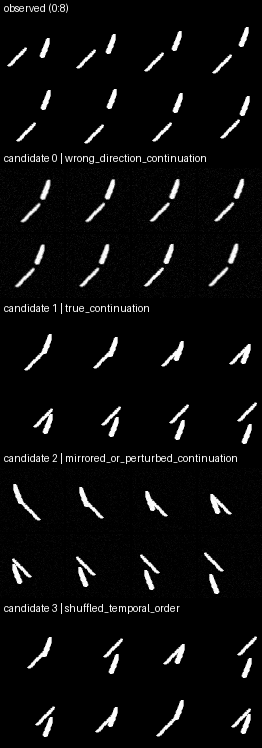

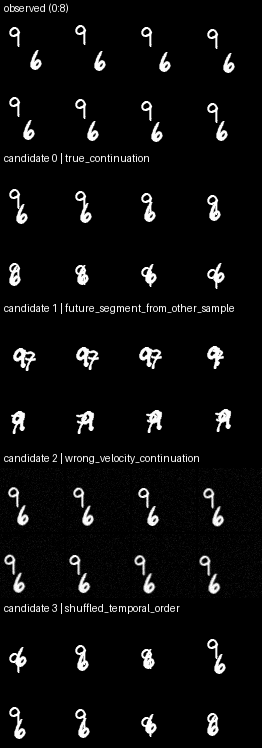

In [6]:
from IPython.display import Image as NotebookImage, display

moving_results_dir = REPO_ROOT / 'results' / 'moving_mnist'
task_results_dir = REPO_ROOT / 'results' / 'task_examples'
moving_paths = save_sample_visualizations(train_dataset, moving_results_dir, sample_indices=(0, 1, 2), max_frames=8)
task_paths = save_future_selection_examples([task_dataset[i] for i in range(3)], task_results_dir, max_examples=3)

print('Saved Moving MNIST artifacts:')
for path in moving_paths:
    print(f'- {path}')

print('\nSaved task example artifacts:')
for path in task_paths:
    print(f'- {path}')

panel_paths = [path for path in task_paths if path.name.endswith('_panel.png')]
for panel_path in panel_paths[:2]:
    display(NotebookImage(filename=str(panel_path)))

## 5. Agent Pipeline Demo

The agent layer is currently a placeholder skeleton designed to run end-to-end. It exposes explicit planner, evaluator, critic, and executive roles, and produces ranked candidates, critique messages, a final selection, and structured trace logs. The scoring logic is deliberately simple so a learned representation model can be plugged in later.

In [7]:
import json

agent_results_dir = REPO_ROOT / 'results' / 'agent_demo'
agent_results_dir.mkdir(parents=True, exist_ok=True)

result = run_future_selection_pipeline(
    observed=example.observed,
    candidates=example.candidates,
    candidate_metadata=example.metadata['candidate_strategies'],
)

print(f'Correct candidate index: {example.correct_index}')
print(f'Selected candidate index: {result.selected_index}')
print('\nRanked candidates:')
for item in result.ranked_candidates:
    print(f'- candidate {item.candidate_index}: score={item.score:.4f}, type={item.generation_type}, rationale={item.rationale}')

print('\nCritiques:')
for critique in result.critique_messages:
    print(f'- [{critique.severity}] candidate {critique.candidate_index}: {critique.message}')

trace_path = agent_results_dir / 'example_trace.json'
trace_path.write_text(json.dumps(result.as_dict(), indent=2), encoding='utf-8')
print(f'\nSaved trace log to: {trace_path}')

Correct candidate index: 1
Selected candidate index: 1

Ranked candidates:
- candidate 1: score=0.6261, type=true_continuation, rationale=true_continuation candidate; strongest heuristic was direction (0.967).
- candidate 3: score=0.3912, type=shuffled_temporal_order, rationale=shuffled_temporal_order candidate; strongest heuristic was direction (0.940).
- candidate 0: score=0.3805, type=wrong_direction_continuation, rationale=wrong_direction_continuation candidate; strongest heuristic was smoothness (0.896).
- candidate 2: score=0.3119, type=mirrored_or_perturbed_continuation, rationale=mirrored_or_perturbed_continuation candidate; strongest heuristic was speed (0.966).

Critiques:
- [info] candidate 1: Candidate 1 is the strongest continuation candidate with score 0.626.
- [warning] candidate 3: Candidate 3 looks plausible but its shuffled_temporal_order construction leaves trajectory inconsistencies. Plan note: Observed clip is treated as context and candidate futures are compared a

## 6. Metrics

These metrics are only meant to validate the plumbing for now. Since the agent uses placeholder motion heuristics rather than a trained representation model, this section should be read as a pipeline sanity check rather than a final performance claim.

In [8]:
import json
from collections import Counter

evaluation_count = 32
correct = 0
strategy_counter = Counter()
selection_counter = Counter()

for idx in range(evaluation_count):
    task_example = task_dataset[idx]
    pipeline_result = run_future_selection_pipeline(
        observed=task_example.observed,
        candidates=task_example.candidates,
        candidate_metadata=task_example.metadata['candidate_strategies'],
    )
    if pipeline_result.selected_index == task_example.correct_index:
        correct += 1
    selection_counter[pipeline_result.selected_index] += 1
    for item in task_example.metadata['candidate_strategies']:
        strategy_counter[item['strategy']] += 1

metrics = {
    'evaluation_count': evaluation_count,
    'accuracy': correct / evaluation_count,
    'selection_histogram': dict(selection_counter),
    'candidate_strategy_histogram': dict(strategy_counter),
}

metrics_path = agent_results_dir / 'metrics.json'
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')
print(metrics)
print(f'Saved metrics to: {metrics_path}')

{'evaluation_count': 32, 'accuracy': 0.78125, 'selection_histogram': {1: 9, 0: 7, 2: 10, 3: 6}, 'candidate_strategy_histogram': {'wrong_direction_continuation': 21, 'true_continuation': 32, 'mirrored_or_perturbed_continuation': 15, 'shuffled_temporal_order': 21, 'future_segment_from_other_sample': 17, 'wrong_velocity_continuation': 22}}
Saved metrics to: /content/jepa-representation-learning/results/agent_demo/metrics.json


## 7. Saved Artifacts

The notebook now writes qualitative and quantitative artifacts into the repository so later world-model and agent experiments have a documented starting point.

In [9]:
artifact_roots = [
    REPO_ROOT / 'results' / 'moving_mnist',
    REPO_ROOT / 'results' / 'task_examples',
    REPO_ROOT / 'results' / 'agent_demo',
]

for root in artifact_roots:
    print(f'Artifacts under {root}:')
    if not root.exists():
        print('  - missing')
        continue
    for path in sorted(root.iterdir()):
        print(f'  - {path.name}')

Artifacts under /content/jepa-representation-learning/results/moving_mnist:
  - train_sample_000.gif
  - train_sample_000_grid.png
  - train_sample_001.gif
  - train_sample_001_grid.png
  - train_sample_002.gif
  - train_sample_002_grid.png
Artifacts under /content/jepa-representation-learning/results/task_examples:
  - future_selection_000_candidate_0.png
  - future_selection_000_candidate_1.png
  - future_selection_000_candidate_2.png
  - future_selection_000_candidate_3.png
  - future_selection_000_panel.png
  - future_selection_001_candidate_0.png
  - future_selection_001_candidate_1.png
  - future_selection_001_candidate_2.png
  - future_selection_001_candidate_3.png
  - future_selection_001_panel.png
  - future_selection_002_candidate_0.png
  - future_selection_002_candidate_1.png
  - future_selection_002_candidate_2.png
  - future_selection_002_candidate_3.png
  - future_selection_002_panel.png
Artifacts under /content/jepa-representation-learning/results/agent_demo:
  - example